# Introduction to Machine Learning -- MC886
# Assignment 2 - Model Selection and Regularization

**Professor:** Marcelo da Silva Reis  
**PED:** Daniel Gardin Gratti  
**PAD:** Guilherme Henrique Ichiro Seto Ito

In [1]:
# Please, enter your name and RA number in the lines below:
print("Thiago Dorta", "|", "231413")
print("Gabriel Melo Lucena", "|", "184254")

Thiago Dorta | 231413
Gabriel Melo Lucena | 184254


---

## Objective

This assignment investigates the effects of overfitting in different data regimes
and test conditions.
The goal is to understand the different results of regularization when data
availability changes, and how they impact the generalization across two different
distributions.

### Guidelines

> Please read these guidelines carefully.

1. Questions can be answered in English or in Portuguese.

2. Use data visualization as a primary tool for understanding the problem. Inspect the training data, corrupted inputs, and model behavior. When an assumption is uncertain, verify it empirically through plots.

3. The provided code serves only as a reference. Modifications are allowed, including changes to functions and the introduction of new components. Code clarity and organization are required.

4. The use of generative AI tools (e.g., ChatGPT, GitHub Copilot, DeepSeek, LLaMA) is permitted strictly for implementation support. The use of AI for interpreting, analyzing, or discussing experimental results is discouraged. Submissions must include:
   - A declaration of which models were used.
   - The prompts that generated any incorporated code.

5. Do not hesitate to reach out to the PED/PAD via Discord.

### About the Dataset

This assignment uses the [MNIST](https://web.archive.org/web/20240213122836/http://yann.lecun.com/exdb/mnist/) dataset, a standard benchmark for image classification. It consists of 28×28 grayscale images of handwritten digits (0–9), where each pixel encodes an intensity value in [0, 255].

MNIST is useful here because it is simple enough that a linear model can do well on it, which means the learned weights are directly interpretable as images, where each weight corresponds to the influence of each pixel.

To study robustness and distribution shift, this assignment uses corrupted variants from [MNIST-C](https://github.com/google-research/mnist-c), which applies systematic corruptions to the original images.

The training set consists entirely of corrupted images. The test set contains **two splits**:
- `test_corrupted`: corrupted test images (same distribution as training).
- `test_clean`: the original, uncorrupted MNIST test images.

Performance on `test_corrupted` measures how well the model learned the training task.
Performance on `test_clean` measures how well the model learned digit recognition.

Your job is to train three different models, each one with different number of
available samples:
- Full-data (60000 samples)
- Partial-data (10000 samples)
- Scarce-data (1000 samples)

Finding the best combination of hyper-parameter for each one of them.

In [2]:
from typing import Any

from numpy.typing import NDArray
import numpy as np
import pandas as pd
import random

import torch
import torch.nn as nn
from torch import optim

import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility.
# Do not tune this number
# Re-run the notebook from the beginning before submitting.
seed = 42
torch.random.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [3]:
# The dataset is available in the classroom assignment.
# Ensure you have downloaded it and placed it alongside this notebook.

# DO NOT change this cell

def subsample_dataset(
    X: NDArray[Any], y: NDArray[Any], n: int
) -> tuple[NDArray[Any], NDArray[Any]]:
    n_samples = len(y)

    idxs = np.random.choice(
        n_samples, size=n, replace=False
    )

    return X[idxs], y[idxs]

X_full = np.load("data/train/train_images.npy")
y_full = np.load("data/train/train_labels.npy")

X_partial, y_partial = subsample_dataset(X_full, y_full, 10_000)
X_scarce, y_scarce = subsample_dataset(X_full, y_full, 1_000)

print(f"Full-data set: {X_full.shape[0]} samples")
print(f"Partial-data set: {X_partial.shape[0]} samples")
print(f"Scarce-data set: {X_scarce.shape[0]} samples")

Full-data set: 60000 samples
Partial-data set: 10000 samples
Scarce-data set: 1000 samples


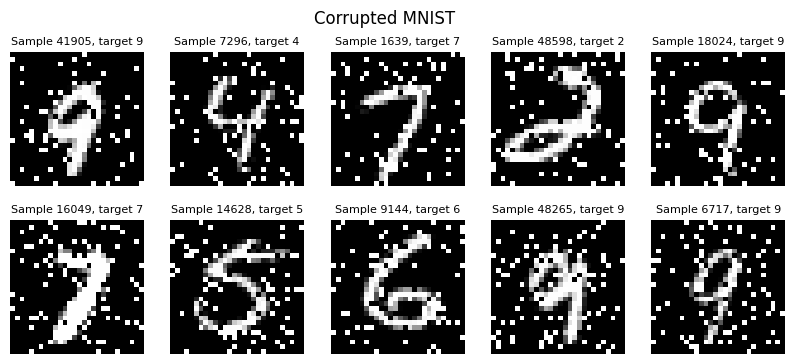

In [4]:
n_cols = 5
n_rows = 2

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2*n_cols, 2*n_rows))

fig.suptitle("Corrupted MNIST")

for i in range(n_rows):
    for j in range(n_cols):
        ax = axs[i, j]
        idx = random.randint(0, len(X_full)-1)

        ax.set_title(f"Sample {idx}, target {y_full[idx]}", fontsize=8)
        ax.imshow(X_full[idx], cmap='grey')
        ax.set_axis_off()

---

## Part 1. Data Analysis and Preprocessing

### 1.1 Exploring the corruption

**(1.0 point)**

Before any modeling, understand what the corruption actually does to the data.

Is the corruption random per-pixel noise, or is it a structured perturbation?
Explore the **training** dataset, understand the distribution and the effects of the introduced
noise.

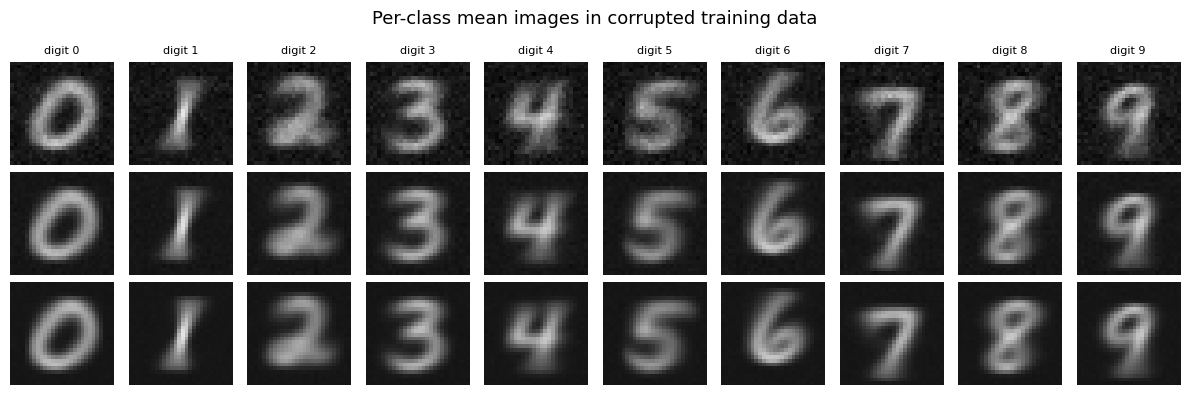

In [5]:
data_regimes = {
    "Scarce": (X_scarce, y_scarce),
    "Partial": (X_partial, y_partial),
    "Full": (X_full, y_full),
}

fig, axs = plt.subplots(len(data_regimes), 10, figsize=(4*len(data_regimes), 4))
for digit in range(10):
    axs[0, digit].set_title(f"digit {digit}", fontsize=8)

for i, name in enumerate(data_regimes):
    X, y = data_regimes[name]


    for digit in range(10):
        mask = (y == digit)
        mean_img = X[mask].mean(axis=0)
        axs[i, digit].imshow(mean_img, cmap="gray", vmin=0, vmax=255)
        axs[i, digit].axis("off")

    axs[i, 0].set_ylabel(f"{name}-data regime", fontsize=9)

plt.suptitle("Per-class mean images in corrupted training data", fontsize=13)
plt.tight_layout()
plt.show()

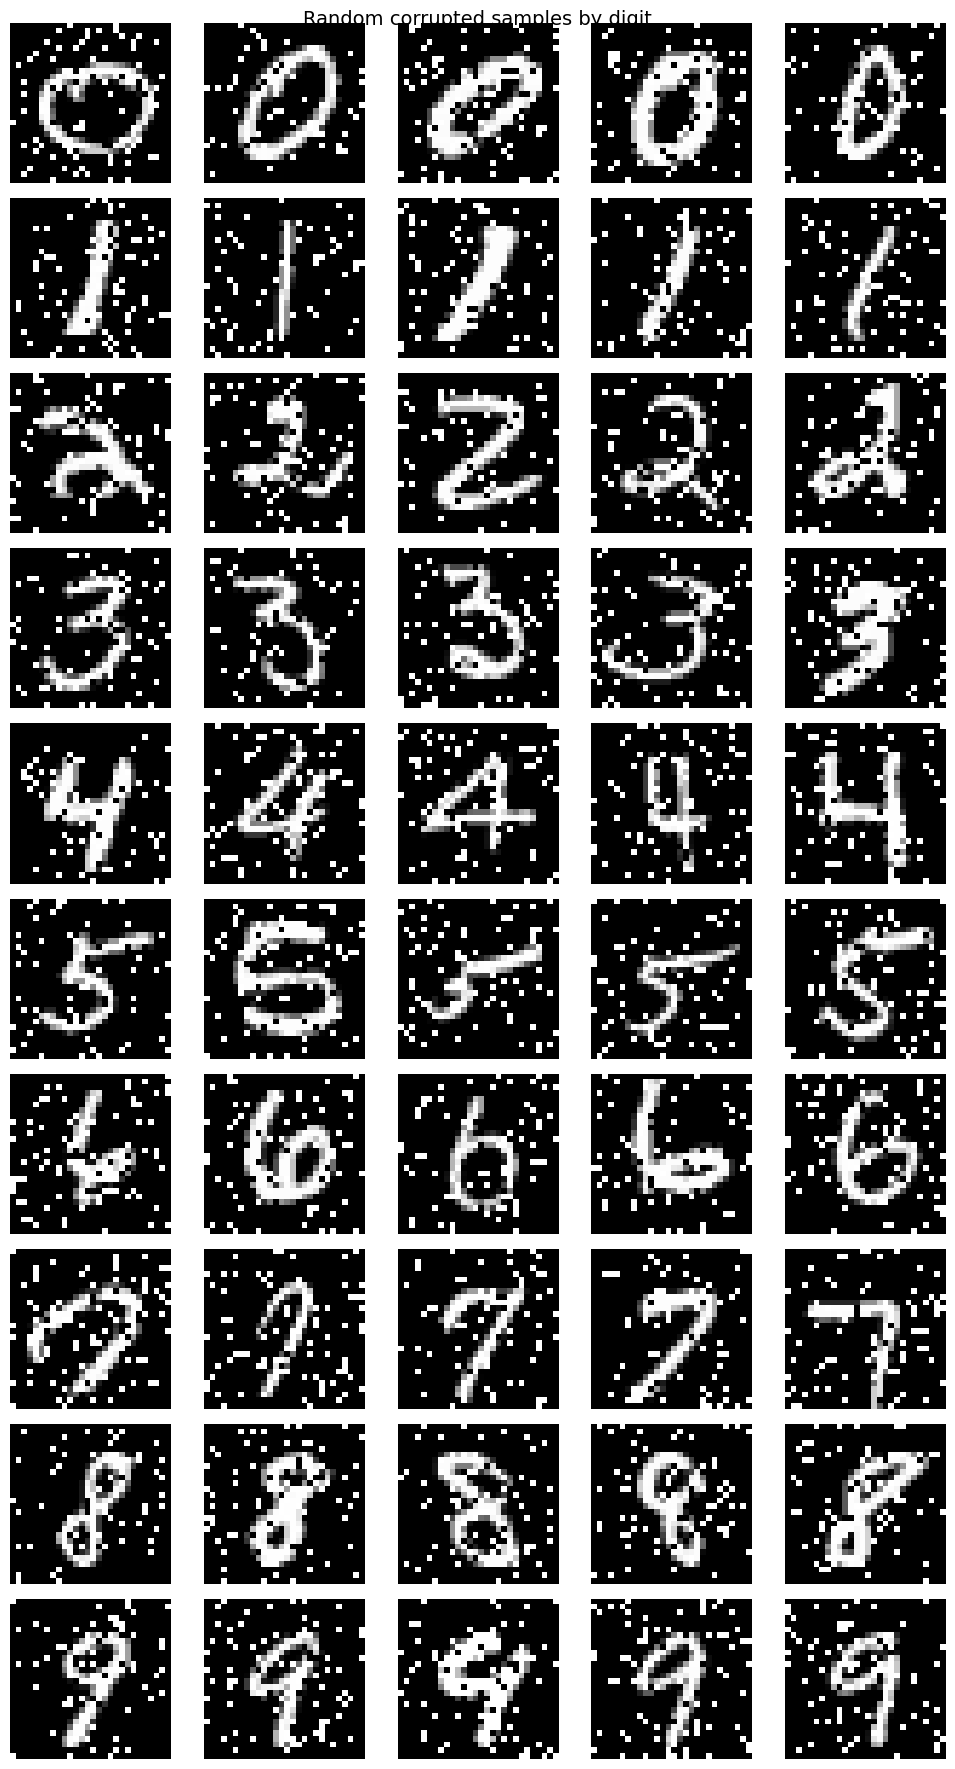

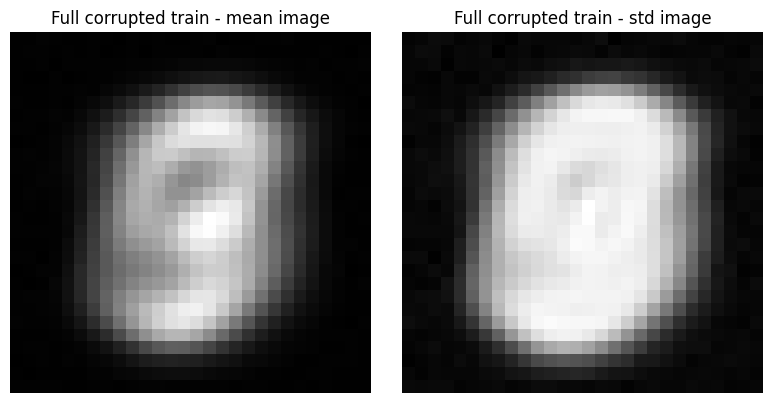

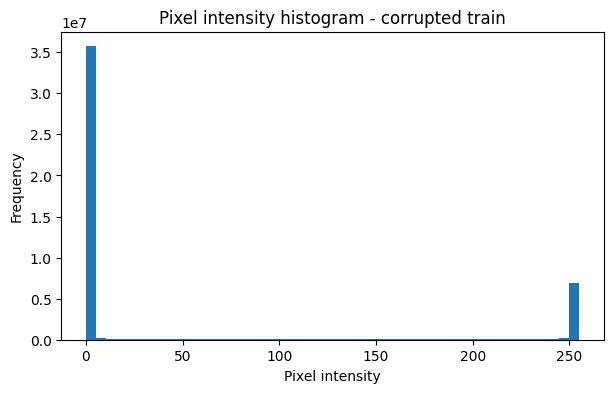

In [6]:
# Implement other visualizations to understand the corruption. 

def show_samples_by_digit(X, y, samples_per_digit=5):
    fig, axs = plt.subplots(10, samples_per_digit, figsize=(2*samples_per_digit, 18))

    for digit in range(10):
        idxs = np.where(y == digit)[0]
        chosen = np.random.choice(idxs, size=samples_per_digit, replace=False)

        for j, idx in enumerate(chosen):
            axs[digit, j].imshow(X[idx].squeeze(), cmap="gray", vmin=0, vmax=255)
            axs[digit, j].axis("off")

            if j == 0:
                axs[digit, j].set_ylabel(f"digit {digit}", fontsize=10)

    plt.suptitle("Random corrupted samples by digit", fontsize=14)
    plt.tight_layout()
    plt.show()


def show_global_mean_and_std(X, title):
    mean_img = X.mean(axis=0).squeeze()
    std_img = X.std(axis=0).squeeze()

    fig, axs = plt.subplots(1, 2, figsize=(8, 4))

    axs[0].imshow(mean_img, cmap="gray")
    axs[0].set_title(f"{title} - mean image")
    axs[0].axis("off")

    axs[1].imshow(std_img, cmap="gray")
    axs[1].set_title(f"{title} - std image")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()


def plot_pixel_histogram(X, title):
    plt.figure(figsize=(7, 4))
    plt.hist(X.flatten(), bins=50)
    plt.title(title)
    plt.xlabel("Pixel intensity")
    plt.ylabel("Frequency")
    plt.show()


show_samples_by_digit(X_full, y_full, samples_per_digit=5)
show_global_mean_and_std(X_full, "Full corrupted train")
plot_pixel_histogram(X_full, "Pixel intensity histogram - corrupted train")

> **Question 1.1**
>
> Describe the corruption. Is it random and per-sample, or is it systematic and shared across images? Does it vary across digit classes?
>
> Are there data regimes where the corruption can effect more than in others?
> Hypothesize how these different regimes will affect a model trained on them.

A corrupção observada nas imagens de treino parece ser majoritariamente formada por pixels brancos espalhados sobre o fundo da imagem, como um ruído do tipo "salt noise". Visualmente, o ruído aparece em posições diferentes para cada amostra, portanto não parece ser uma máscara fixa idêntica aplicada a todas as imagens.

Ao analisar as médias por classe, os dígitos continuam claramente reconhecíveis, o que indica que a estrutura principal do MNIST ainda está presente. Porém, também é possível notar que o fundo das imagens médias não fica totalmente preto, sugerindo que há ruído distribuído pelo fundo. Como esse ruído aparece em muitas imagens, sua média não desaparece completamente.

A corrupção não parece depender fortemente da classe do dígito, pois todos os dígitos apresentam ruído semelhante no fundo. O que varia entre as classes é principalmente a forma média do próprio dígito.

O efeito da corrupção tende a ser mais prejudicial no scarce-data, com apenas 1000 amostras, pois há menos exemplos para o modelo distinguir entre padrões reais dos dígitos e ruídos acidentais. Nesse caso, o modelo pode atribuir pesos a pixels ruidosos que apareceram por acaso em certas classes. No regime full-data, com 60000 amostras, o ruído aleatório tende a se cancelar melhor estatisticamente, permitindo que o modelo aprenda padrões mais estáveis dos dígitos.

### 1.2 Preprocessing

**(1.0 point)**

Before training, the raw data must be brought into a form suitable for gradient-based optimization.

Two considerations are important here:

1. **Scale.** Raw pixel values are in [0, 255]. Gradient descent is sensitive to the scale of inputs; large input values produce large gradients, which can destabilize training.

2. **Data leakage.** Any statistics used for preprocessing must be computed from the training set only, then applied to all other splits.
Computing statistics on the full dataset, including test data, leaks information about the test distribution into preprocessing and invalidates evaluation.

In [7]:
# Implement the preprocessing on all data-regimes. You can use scikit-learn, or other libraries.

def preprocess_images(X: NDArray[Any]) -> NDArray[np.float32]:
    """
    Convert images from uint8 [0, 255] to float32 [0, 1]
    and flatten from 28x28x1 to 784.
    """
    X = X.astype(np.float32) / 255.0
    X = X.reshape(X.shape[0], -1)
    return X


X_full_proc = preprocess_images(X_full)
X_partial_proc = preprocess_images(X_partial)
X_scarce_proc = preprocess_images(X_scarce)

data_regimes_proc = {
    "Scarce": (X_scarce_proc, y_scarce),
    "Partial": (X_partial_proc, y_partial),
    "Full": (X_full_proc, y_full),
}

print("Full:", X_full_proc.shape, y_full.shape)
print("Partial:", X_partial_proc.shape, y_partial.shape)
print("Scarce:", X_scarce_proc.shape, y_scarce.shape)

Full: (60000, 784) (60000,)
Partial: (10000, 784) (10000,)
Scarce: (1000, 784) (1000,)


> **Question 1.2**
>
> Describe the preprocessing choices made above. What strategy have you chosen, and why?

Os pixels foram convertidos de inteiros no intervalo [0, 255] para valores em ponto flutuante no intervalo [0, 1], dividindo todos os valores por 255. Essa normalização reduz a escala das entradas e torna o treinamento por gradiente descendente mais estável. Além disso, cada imagem 28×28×1 foi transformada em um vetor de 784 atributos, pois a regressão logística multinomial implementada como uma camada linear recebe vetores como entrada.

Quanto ao data leakage, a divisão por 255 utiliza uma constante do domínio do problema e não estatísticas computadas a partir dos dados, portanto não há risco de vazamento de informação do conjunto de teste para o treino. Caso fosse utilizada uma normalização baseada em média e desvio padrão, esses valores deveriam ser estimados exclusivamente a partir do conjunto de treino de cada fold e aplicados também ao conjunto de validação, evitando que informações do conjunto de validação influenciem o pré-processamento.

---

## Part 2. Multinomial Logistic Regression

### 2.1 The model

Multinomial logistic regression (also called softmax regression) is the natural extension of binary logistic regression to $K > 2$ classes.

Given an input $\mathbf{x} \in \mathbb{R}^d$, the model computes a score (logit) for each class $k$:

$$z_k = \mathbf{w}_k^\top \mathbf{x} + b_k$$

Each logit is an unconstrained real number, in order to transform these values into
probabilities, where $p_k \geq 0$ and $\sum_k p_k = 1$, the softmax function
is used:

$$P(y = k \mid \mathbf{x}) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

Training minimizes the **cross-entropy loss**, which is the negative log-likelihood of the true class under this distribution:

$$\mathcal{L}(\mathbf{W}, \mathbf{b}) = -\frac{1}{N} \sum_{i=1}^{N} \log P(y_i \mid \mathbf{x}_i)$$

For MNIST with $d = 784$ pixels and $K = 10$ classes, the weight matrix $\mathbf{W} \in \mathbb{R}^{10 \times 784}$ has one row per class. Each row $\mathbf{w}_k$ can be reshaped into a 28×28 image and visualized directly: positive values indicate pixels whose brightness increases the log-odds of class $k$, whereas negative values suppress it.
This direct interpretability is one reason we use a linear model here.

### 2.2 Regularization

Standard cross-entropy minimization has no preference over the parameter space.
With enough capacity, or with corrupted data that contains spurious features, the model can assign large weights to uninformative or noisy pixels if doing so reduces training loss.

Regularization considers an additional assumption over the nature of the learned weights,
adding a penalty on the weights to the loss:

$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \lambda \cdot \Omega(\mathbf{W})$$

Two common choices for $\Omega$:

- **L2 (Ridge):** $\Omega(\mathbf{W}) = \|\mathbf{W}\|_2^2 = \sum_{k,j} w_{kj}^2$. Penalizes large weights uniformly, where all weights shrink toward zero but none are forced exactly to zero.
In PyTorch's optimizers, L2 is implemented as `weight_decay`.

- **L1 (Lasso):** $\Omega(\mathbf{W}) = \|\mathbf{W}\|_1 = \sum_{k,j} |w_{kj}|$. Penalizes the sum of absolute values, producing sparse solutions where many weights are driven to exactly zero.

The hyperparameter $\lambda \geq 0$ controls the strength of regularization.
$\lambda = 0$ recovers the unregularized problem.

**(2.0 point)**

Implement the Multinomial Logistic Regression model using PyTorch's nn.Module
for the linear model (image as input and logits as outputs), and SGD with both
L1 and L2 regularization methods.

In [8]:
# Implementation goes here

class LinearModel(nn.Module):
    def __init__(self, input_dim: int = 784, n_classes: int = 10):
        super().__init__()
        self.linear = nn.Linear(input_dim, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)


def accuracy(logits: torch.Tensor, y: torch.Tensor) -> float:
    """Fraction of correctly predicted samples."""
    y_pred = logits.argmax(dim=-1)
    return (y == y_pred).float().mean().item()


def l1_penalty(model: nn.Module) -> torch.Tensor:
    penalty = torch.tensor(0.0, device=next(model.parameters()).device)

    for name, param in model.named_parameters():
        # Regularizamos apenas os pesos, não o bias.
        if "weight" in name:
            penalty = penalty + param.abs().sum()

    return penalty


def train(
    model: nn.Module,
    X: torch.Tensor,
    y: torch.Tensor,
    n_iter: int,
    lr: float = 0.1,
    l1: float = 0.0,
    l2: float = 0.0
) -> list[float]:
    """
    Train a model using full-batch SGD with L1/L2 regularization.

    Returns the list of per-iteration training losses.
    """
    criterion = nn.CrossEntropyLoss()

    # L2 em PyTorch pode ser implementado com weight_decay.
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=l2)

    losses = []

    for _ in range(n_iter):
        optimizer.zero_grad()

        logits = model(X)
        loss = criterion(logits, y)

        # L1 é adicionado manualmente à loss.
        if l1 > 0:
            loss = loss + l1 * l1_penalty(model)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return losses


def to_torch(X_np, y_np):
    X_t = torch.tensor(X_np, dtype=torch.float32)
    y_t = torch.tensor(y_np, dtype=torch.long)
    return X_t, y_t

### 2.3 Baseline mode

**(2.0 points)**

Train a unregularized model on each training set and observe the training loss
per iteration on each model during training.

To diagnose and understand what the trained model have learned, we visualize the
learned weights as a heatmap.

In [9]:
# Visualize learned weight images, one per digit class.
# Use a diverging colormap: red = positive weight (pixel increases log-odds),
# blue = negative weight (pixel suppresses log-odds).

def plot_weights(weights: NDArray[np.float32], title: str) -> None:
    fig, axs = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(title, fontsize=13)

    for digit in range(10):
        ax = axs[digit // 5, digit % 5]
        ax.imshow(weights[digit].reshape(28, 28), cmap="icefire")
        ax.set_title(f"digit {digit}", fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

baseline_models = {}
baseline_losses = {}
baseline_train_accs = {}

n_iter_baseline = 1000
lr_baseline = 0.5

for name, (X_np, y_np) in data_regimes_proc.items():
    print(f"Training baseline model: {name}")

    X_t, y_t = to_torch(X_np, y_np)

    model = LinearModel()
    losses = train(
        model,
        X_t,
        y_t,
        n_iter=n_iter_baseline,
        lr=lr_baseline,
        l1=0.0,
        l2=0.0
    )

    with torch.no_grad():
        logits = model(X_t)
        train_acc = accuracy(logits, y_t)

    baseline_models[name] = model
    baseline_losses[name] = losses
    baseline_train_accs[name] = train_acc

    print(f"{name} train accuracy: {train_acc:.4f}")

Training baseline model: Scarce
Scarce train accuracy: 1.0000
Training baseline model: Partial
Partial train accuracy: 0.9594
Training baseline model: Full
Full train accuracy: 0.8982


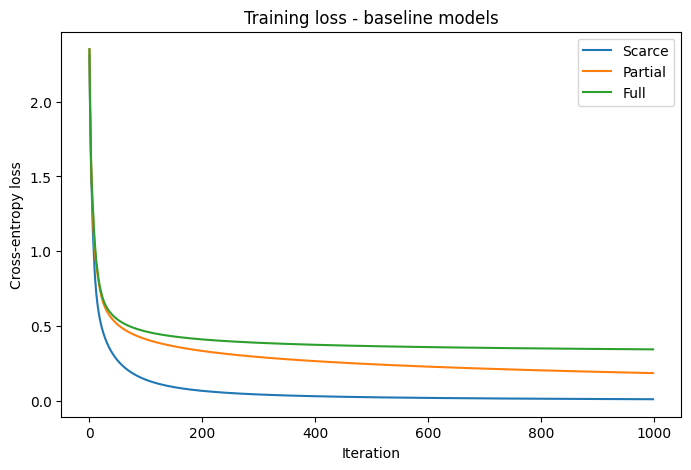

In [10]:
plt.figure(figsize=(8, 5))

for name, losses in baseline_losses.items():
    plt.plot(losses, label=name)

plt.title("Training loss - baseline models")
plt.xlabel("Iteration")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

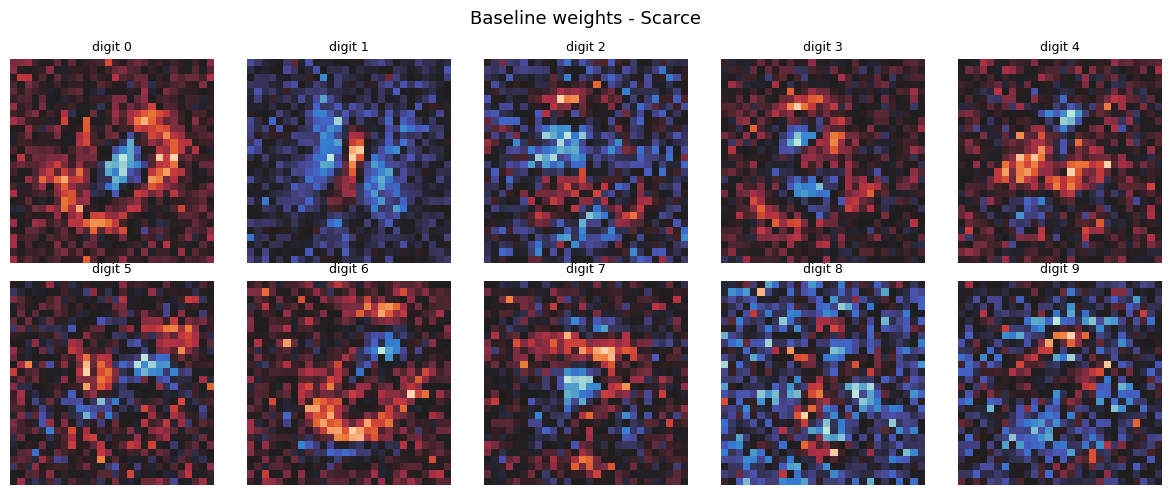

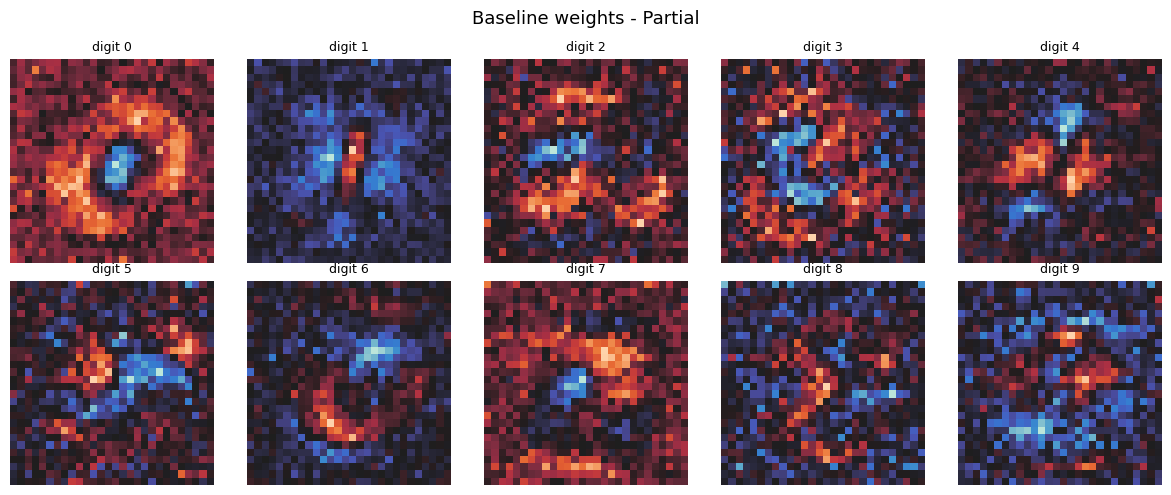

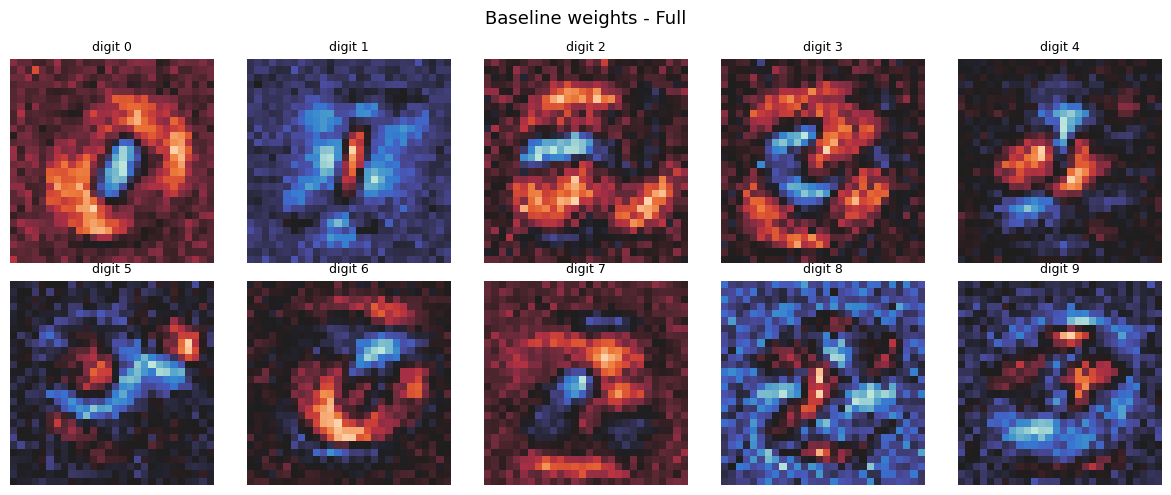

In [11]:
for name, model in baseline_models.items():
    weights = model.linear.weight.detach().cpu().numpy()
    plot_weights(weights, f"Baseline weights - {name}")

> **Question 2.3**
>
> Inspect the weight images for each baseline model. How do you explain the
> weight values in the heatmap, and what patterns do they show?
>
> Compare between the model, how are they different?

Nas imagens de pesos, cada mapa 28×28 representa os pesos aprendidos para uma classe. Regiões com pesos positivos indicam pixels cuja ativação aumenta o logit daquela classe; regiões com pesos negativos indicam pixels que reduzem a evidência para aquela classe.

No modelo sem regularização, os pesos tendem a formar padrões parecidos com os dígitos médios: por exemplo, o mapa da classe 0 destaca regiões em formato circular, enquanto o da classe 1 destaca uma região mais vertical. Isso mostra que, mesmo sendo linear, o modelo consegue aprender características discriminativas dos dígitos.

Comparando os regimes, o modelo Full apresenta pesos mais suaves e mais estruturados, pois há mais exemplos e o efeito do ruído aleatório é reduzido pela quantidade de dados. O modelo Partial ainda mantém boa estrutura, mas pode apresentar mais irregularidades. O modelo Scarce tende a apresentar pesos mais ruidosos e menos estáveis, pois com poucos dados o modelo pode atribuir importância a pixels corrompidos que apareceram por acaso no conjunto de treino.

Assim, a principal diferença entre os modelos está na estabilidade dos pesos: quanto menor o conjunto de dados, maior a tendência de overfitting ao ruído da corrupção.

---

## Part 3. Regularization

**(2.0 points)**

We now introduce regularization and sweep over $\lambda$ values for both L1 and L2 penalties.

Your **only decision criterion** in this part is cross-validation accuracy computed on the corrupted training data, exactly what you would have in a real scenario without access to an unlabeled clean test set.

For each configuration (data regime x reg type x $\lambda$), use K-fold cross-validation to estimate validation accuracy.
Then, for each regularizer, **select the best $\lambda$** by CV and train a final model on the full training set.
Store the final models, they will be evaluated after model selection is complete.

> **Decision task** Report, per regularizer and data regimes, which $\lambda$ you selected and why.
Inspect the weight images of your chosen models and describe what you observe.


Scarce | L1 | lambda=0e+00 | CV acc = 0.8090
Scarce | L1 | lambda=1e-04 | CV acc = 0.8220
Scarce | L1 | lambda=1e-03 | CV acc = 0.8180
Scarce | L1 | lambda=1e-02 | CV acc = 0.6000
Scarce | L1 | lambda=1e-01 | CV acc = 0.2650
Scarce | L1 | lambda=1e+00 | CV acc = 0.2000
  >> Best: lambda=0.0001 | acc=0.8220

Scarce | L2 | lambda=0e+00 | CV acc = 0.8120
Scarce | L2 | lambda=1e-04 | CV acc = 0.8180
Scarce | L2 | lambda=1e-03 | CV acc = 0.8120
Scarce | L2 | lambda=1e-02 | CV acc = 0.8100
Scarce | L2 | lambda=1e-01 | CV acc = 0.7820
Scarce | L2 | lambda=1e+00 | CV acc = 0.3680
  >> Best: lambda=0.0001 | acc=0.8180

Partial | L1 | lambda=0e+00 | CV acc = 0.8585
Partial | L1 | lambda=1e-04 | CV acc = 0.8591
Partial | L1 | lambda=1e-03 | CV acc = 0.8556
Partial | L1 | lambda=1e-02 | CV acc = 0.5824
Partial | L1 | lambda=1e-01 | CV acc = 0.2452
Partial | L1 | lambda=1e+00 | CV acc = 0.2863
  >> Best: lambda=0.0001 | acc=0.8591

Partial | L2 | lambda=0e+00 | CV acc = 0.8574
Partial | L2 | lambda

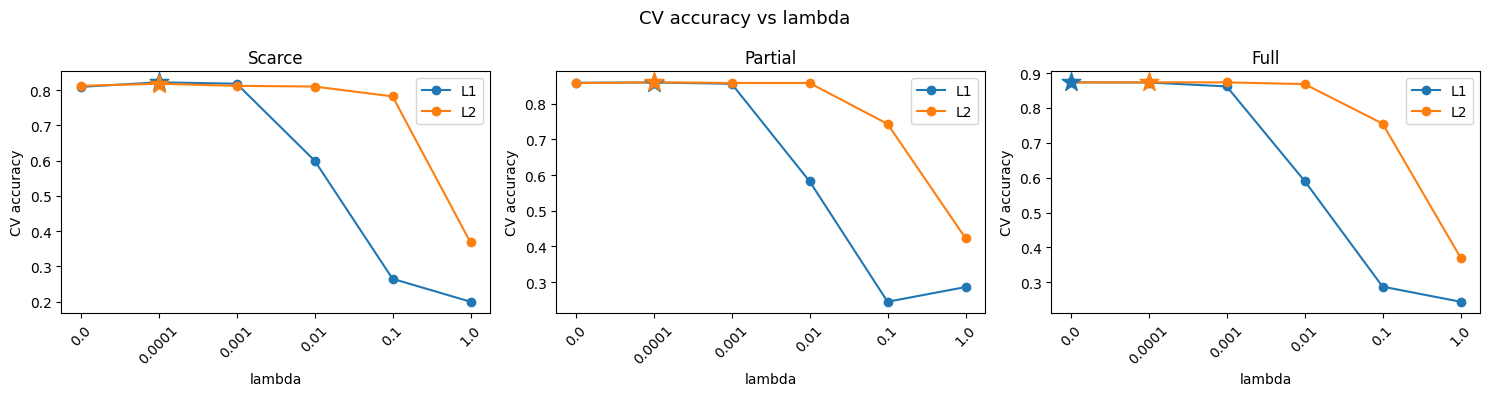

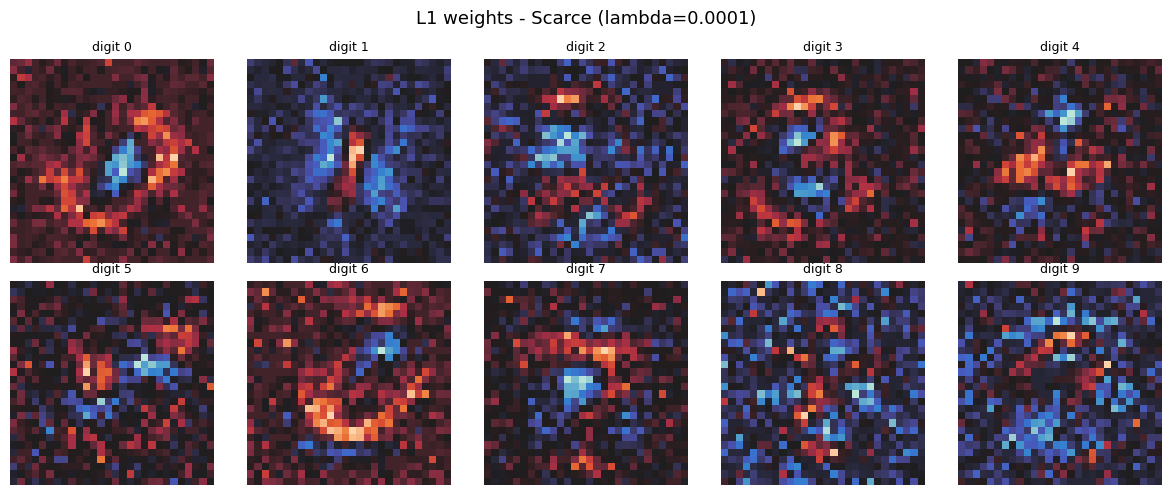

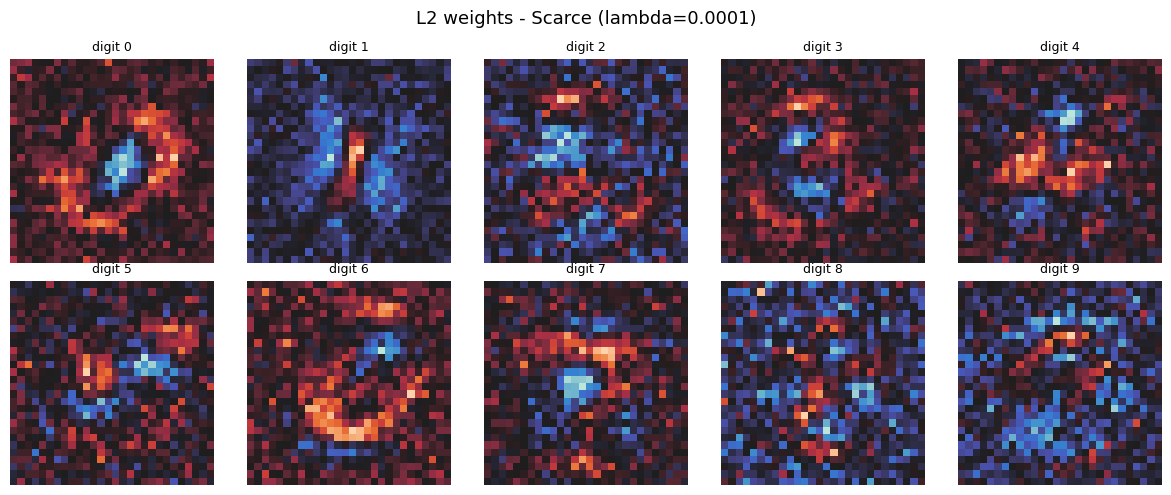

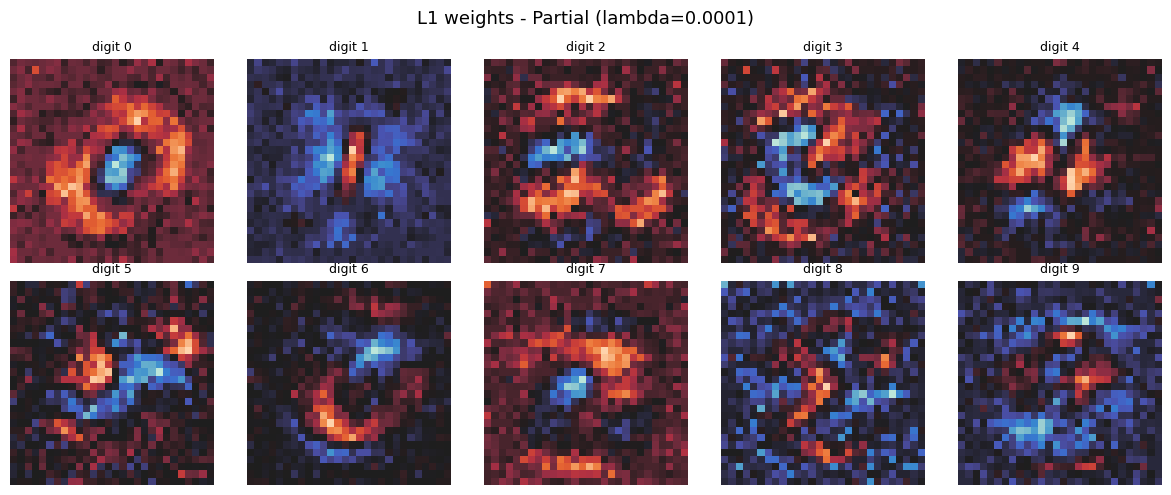

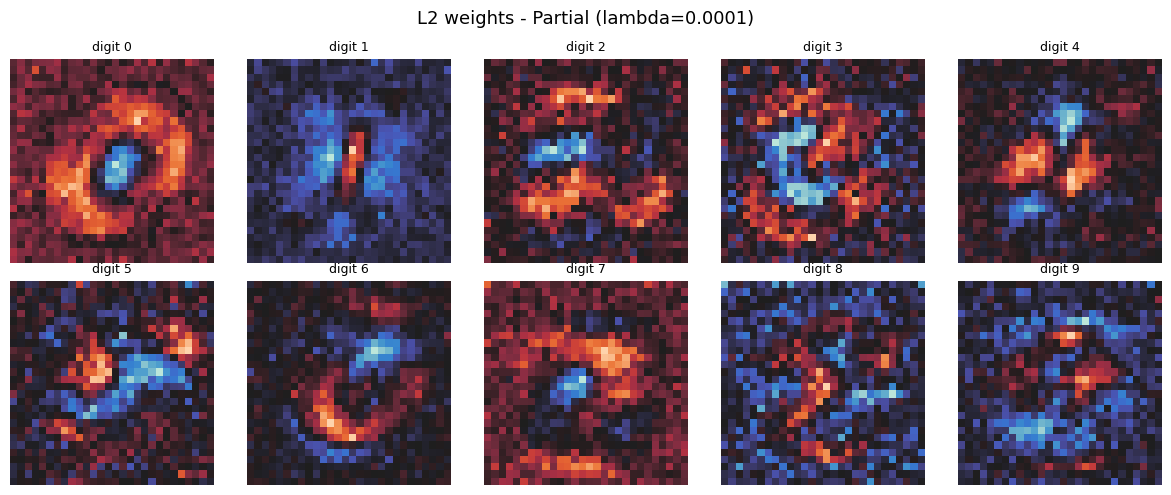

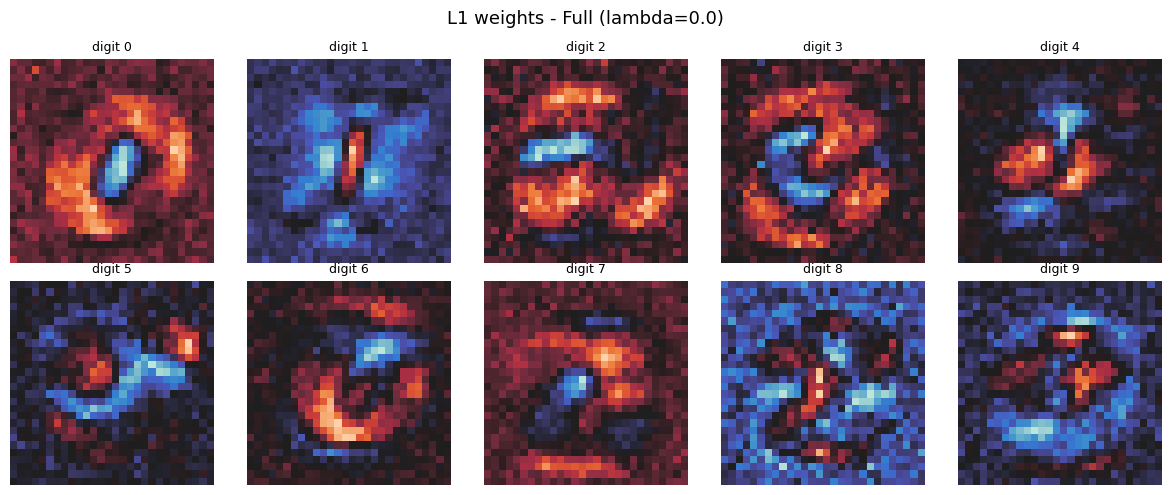

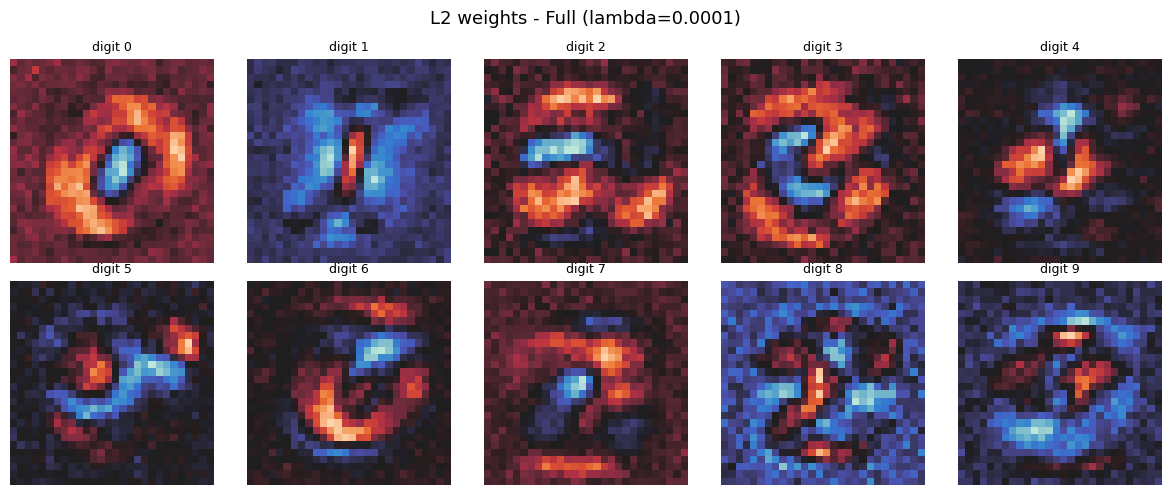

In [12]:
from sklearn.model_selection import KFold

lambda_values = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
n_folds = 3
n_iter_cv = 200
lr_cv = 0.5

def cross_val_accuracy(X_raw, y, l1, l2):
    # Usar kfold do sklearn
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    
    accs = []
    
    for train_idx, val_idx in kf.split(X_raw):
        # para cada elemento, processamos a imagem
        X_tr_proc = preprocess_images(X_raw[train_idx])
        X_val_proc = preprocess_images(X_raw[val_idx])
        y_tr, y_val = y[train_idx], y[val_idx]
        X_tr_t, y_tr_t = to_torch(X_tr_proc, y_tr)
        X_val_t, y_val_t = to_torch(X_val_proc, y_val)
    
        model = LinearModel()
        # treinamos o modelo com cada um dos hiperparametros 
    
        train(model, X_tr_t, y_tr_t, n_iter=n_iter_cv, lr=lr_cv, l1=l1, l2=l2)
    
        with torch.no_grad():
            acc = accuracy(model(X_val_t), y_val_t)
    
        # calculamos a acuaria de cada treino
        accs.append(acc)
        # no fim calculamos a media da acuracia
    return np.mean(accs)


cv_results = {}
best_lambdas = {}
# vamos anotar os modelos
all_final_models = {}

for regime_name, (X_raw, y_np) in data_regimes.items():
    cv_results[regime_name] = {"L1": {}, "L2": {}}
    
    best_lambdas[regime_name] = {}

    all_final_models[regime_name] = {"L1": {}, "L2": {}}

    for reg_type in ["L1", "L2"]:
        best_lam = None
        best_acc = -1

        for lam in lambda_values:
            # para cada uma das combinações possiveis de reg type, l1, l2, dados
            
            l1 = lam if reg_type == "L1" else 0.0
            l2 = lam if reg_type == "L2" else 0.0
            
            # calculamos acuracia media
            
            acc = cross_val_accuracy(X_raw, y_np, l1=l1, l2=l2)
            cv_results[regime_name][reg_type][lam] = acc
            
            print(f"{regime_name} | {reg_type} | lambda={lam:.0e} | CV acc = {acc:.4f}")
            
            if acc > best_acc:
                # escolhemos a melhor
                best_acc = acc
                best_lam = lam

        best_lambdas[regime_name][reg_type] = best_lam
        print(f"  >> Best: lambda={best_lam} | acc={best_acc:.4f}\n")

    X_t, y_t = to_torch(*data_regimes_proc[regime_name])
    for reg_type in ["L1", "L2"]:
        all_final_models[regime_name][reg_type][0.0] = baseline_models[regime_name]
        for lam in lambda_values[1:]:
            l1 = lam if reg_type == "L1" else 0.0

            l2 = lam if reg_type == "L2" else 0.0
            m = LinearModel()
            train(m, X_t, y_t, n_iter=500, lr=0.5, l1=l1, l2=l2)
            
            all_final_models[regime_name][reg_type][lam] = m

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
#PROMPT: Claude AI Para cada um dos regimes queremos um plot e um scatter mostrando os resultados
for i, regime_name in enumerate(["Scarce", "Partial", "Full"]):
    ax = axs[i]
    for reg_type in ["L1", "L2"]:
        accs = [cv_results[regime_name][reg_type][lam] for lam in lambda_values]
        ax.plot(range(len(lambda_values)), accs, marker='o', label=reg_type)
        best_idx = lambda_values.index(best_lambdas[regime_name][reg_type])
        ax.scatter([best_idx], [accs[best_idx]], marker='*', s=200, zorder=5)
    ax.set_xticks(range(len(lambda_values)))
    ax.set_xticklabels([str(lam) for lam in lambda_values], rotation=45)
    ax.set_title(regime_name)
    ax.set_xlabel("lambda")
    ax.set_ylabel("CV accuracy")
    ax.legend()
plt.suptitle("CV accuracy vs lambda", fontsize=13)
plt.tight_layout()
plt.show()

for regime_name in ["Scarce", "Partial", "Full"]:
    for reg_type in ["L1", "L2"]:
        best_lam = best_lambdas[regime_name][reg_type]
        best_model = all_final_models[regime_name][reg_type][best_lam]
        weights = best_model.linear.weight.detach().cpu().numpy()
        # plotar os pesos do melhor modelo 
        plot_weights(weights, f"{reg_type} weights - {regime_name} (lambda={best_lam})")


> **Question 4**
>
> (a) As $\lambda$ increases for L2 regularization, how does CV accuracy change on each data regime?
> Are there clear optima, or does accuracy plateau?
>
> (b) Compare the weight images of the CV-selected L2 model, the CV-selected L1 model, and the unregularized baseline. What differences do you observe in terms of structure and sparsity?
>
> (c) Connect the weight images to the corruption structure identified in Part 1. Does the CV-selected model appear to have suppressed the corruption pattern, amplified it, or is it ambiguous from weights alone?
>
> (d) **Predict**, based on what you see in the weights and CV curves, which of your three CV-selected models (none / L2 / L1) you expect will perform best on clean, uncorrupted images — and which worst. Justify your prediction before seeing any test results.


**(a)** Em L2 temos que a acurácia é consistente e similar para todos os regimes até lambda = 0.01, de forma que o regime Scarce consegue estender esse patamar ate 0.1, mas para Partial e full já caem a acurácia a medida que aumenta o lambda, ficando claro o excesso de regularização a ponto de prejudicar a acruácia.

**(b)** Parecem que os pesos dos modelos escolhidos em termos de estrutura parece ter identificado melhor bordas tornando-as mais bem definidas e a intensidade/cores parecem ter se tornado mais consistente na identificação, de forma que diminui a esparsidade do ruído.

**(c)** A corrupção da Part 1 são principalmente pixels brancos espalhados aleatoriamente principalmente no fundo das imagens. Nos pesos do baseline, esses pixels de fundo recebem pesos não nulos já que apareceram sistematicamente em algumas classes durante o treino. Enquanto a regularização tende a zerar pesos em regiões pouco informativas, coindidindo com o fundo ruidoso. Os pesos dos modelos regularizados mostram fundos mais uniformes e semelhantes, sugerindo supressão parcial do padrão de corrupção. Parece que L1 suprime ainda mais "forte", enquanto L2 de forma mais gradual.

**(d)** Com base nesses pesos que vimos e nas curvas de acurácia, parece que L2 e L1 com lambdas ótimos devem ter bons resultados melhores que o baseline com imagens limpas, visto que a regularização reduz o impacto dos pixels ruidosos do treino. Esperamos que L1 impacte mais ao zerar completamente os pesos do fundo, enquanto que o baseline vai ter aprendido o "padrão" do ruído do fundo, para o regime full com CV de lambda 0 para L1 devemos ver uma diferença menor.

---

## Part 4. Test

**(2.0 points)**

Until now, all decisions, dataset size analysis, regularization selection, were made using only the corrupted training data and cross-validation.
**Now we use the test sets** to evaluate the models you selected.

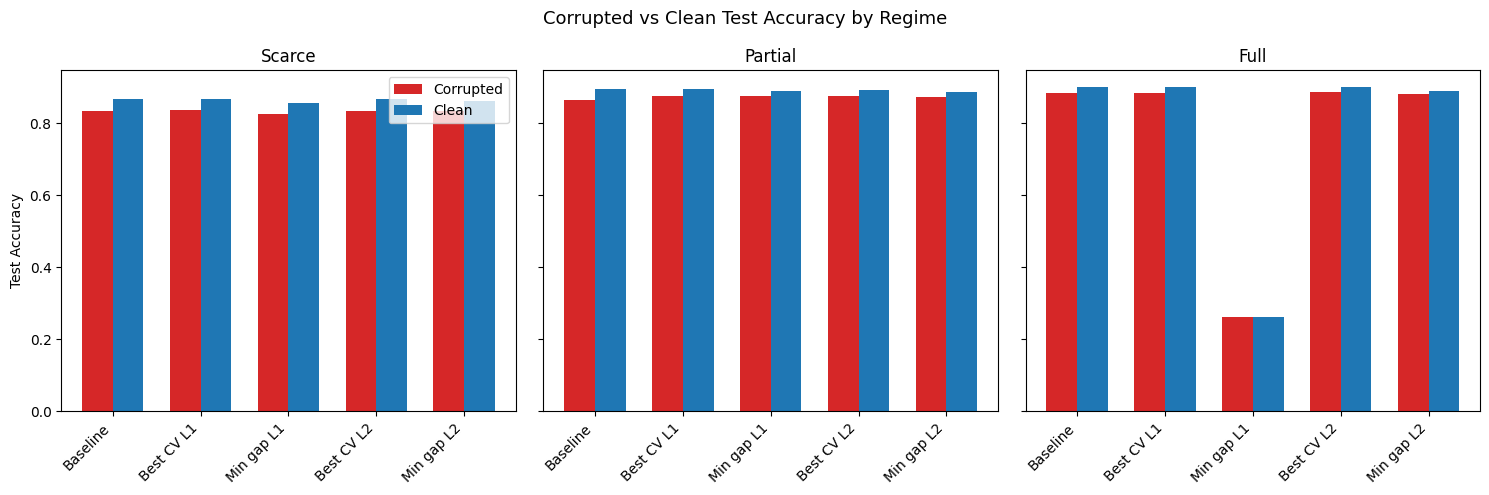

 Regime      Model  lambda  CV acc  Test corr  Test clean     Gap    Criterion
 Scarce   Baseline  0.0000  0.8090     0.8332      0.8675 -0.0343       no reg
 Scarce Best CV L1  0.0001  0.8220     0.8353      0.8668 -0.0315      best CV
 Scarce Min gap L1  0.0010  0.8180     0.8267      0.8568 -0.0301 smallest gap
 Scarce Best CV L2  0.0001  0.8180     0.8342      0.8684 -0.0342      best CV
 Scarce Min gap L2  0.0100  0.8100     0.8343      0.8615 -0.0272 smallest gap
Partial   Baseline  0.0000  0.8585     0.8642      0.8937 -0.0295       no reg
Partial Best CV L1  0.0001  0.8591     0.8764      0.8945 -0.0181      best CV
Partial Min gap L1  0.0010  0.8556     0.8743      0.8889 -0.0146 smallest gap
Partial Best CV L2  0.0001  0.8597     0.8741      0.8922 -0.0181      best CV
Partial Min gap L2  0.0100  0.8577     0.8719      0.8854 -0.0135 smallest gap
   Full   Baseline  0.0000  0.8734     0.8845      0.9016 -0.0171       no reg
   Full Best CV L1  0.0000  0.8734     0.8845      0

In [14]:
X_test_corr = np.load("data/test/test_images.npy")
y_test_corr = np.load("data/test/test_labels.npy")
X_test_clean = np.load("data/test/clean_images.npy")
y_test_clean = np.load("data/test/clean_labels.npy")

X_test_corr_proc = preprocess_images(X_test_corr)
X_test_clean_proc = preprocess_images(X_test_clean)

X_test_corr_t, y_test_corr_t = to_torch(X_test_corr_proc, y_test_corr)
X_test_clean_t, y_test_clean_t = to_torch(X_test_clean_proc, y_test_clean)

rows = []
for regime_name in ["Scarce", "Partial", "Full"]:
    with torch.no_grad():
        b_corr = accuracy(baseline_models[regime_name](X_test_corr_t), y_test_corr_t)
        b_clean = accuracy(baseline_models[regime_name](X_test_clean_t), y_test_clean_t)
    rows.append({
        "Regime": regime_name, "Model": "Baseline", "lambda": 0.0,
        "CV acc": round(cv_results[regime_name]["L1"][0.0], 4),
        "Test corr": round(b_corr, 4), "Test clean": round(b_clean, 4),
        "Gap": round(b_corr - b_clean, 4), "Criterion": "no reg"
    })

    for reg_type in ["L1", "L2"]:
        best_lam = best_lambdas[regime_name][reg_type]
        m = all_final_models[regime_name][reg_type][best_lam]
        with torch.no_grad():
            corr = accuracy(m(X_test_corr_t), y_test_corr_t)
            clean = accuracy(m(X_test_clean_t), y_test_clean_t)
        rows.append({
            "Regime": regime_name, "Model": f"Best CV {reg_type}", "lambda": best_lam,
            "CV acc": round(cv_results[regime_name][reg_type][best_lam], 4),
            "Test corr": round(corr, 4), "Test clean": round(clean, 4),
            "Gap": round(corr - clean, 4), "Criterion": "best CV"
        })

        all_gaps = []
        for lam in lambda_values:
            m_lam = all_final_models[regime_name][reg_type][lam]
            with torch.no_grad():
                c = accuracy(m_lam(X_test_corr_t), y_test_corr_t)
                cl = accuracy(m_lam(X_test_clean_t), y_test_clean_t)
            all_gaps.append((abs(c - cl), lam, c, cl))
        all_gaps.sort()
        _, min_lam, min_corr, min_clean = all_gaps[0]
        rows.append({
            "Regime": regime_name, "Model": f"Min gap {reg_type}", "lambda": min_lam,
            "CV acc": round(cv_results[regime_name][reg_type][min_lam], 4),
            "Test corr": round(min_corr, 4), "Test clean": round(min_clean, 4),
            "Gap": round(min_corr - min_clean, 4), "Criterion": "smallest gap"
        })

df_results = pd.DataFrame(rows)

# Generate a grouped bar chart
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

models_order = ["Baseline", "Best CV L1", "Min gap L1", "Best CV L2", "Min gap L2"]
x = np.arange(len(models_order))
width = 0.35

for i, regime_name in enumerate(["Scarce", "Partial", "Full"]):
    ax = axs[i]
    regime_df = df_results[df_results["Regime"] == regime_name].set_index("Model")
    regime_df = regime_df.reindex(models_order)
    
    rects1 = ax.bar(x - width/2, regime_df["Test corr"], width, label='Corrupted', color='tab:red')
    rects2 = ax.bar(x + width/2, regime_df["Test clean"], width, label='Clean', color='tab:blue')
    
    ax.set_title(regime_name)
    ax.set_xticks(x)
    ax.set_xticklabels(models_order, rotation=45, ha="right")
    
    if i == 0:
        ax.set_ylabel("Test Accuracy")
        ax.legend()

plt.suptitle("Corrupted vs Clean Test Accuracy by Regime", fontsize=13)
plt.tight_layout()
plt.show()

print(df_results.to_string(index=False))


> **Question 5**
>
> (a) Describe the shape of the trade-off curve (corrupted-test vs. clean-test). Is there a region where increasing regularization simultaneously improves both accuracies? Is there a region of genuine trade-off?
>
> (b) The CV-selected models are marked on the plot. Where do they fall relative to the trade-off frontier? What does this tell you about using cross-validation as a model selection criterion when training and deployment distributions differ?
>
> (c) Revisit your prediction from Question 4(d). Was it correct? If not, what did the weight images fail to reveal that the test results exposed?
>
> (d) Connect the sparsity plot to the OOD results. Why might L1 regularization behave differently from L2 when evaluated on clean images?
>
> (e) In a real deployment scenario, the clean test set would not be available during model selection. Given only corrupted validation data, what practical strategies could a practitioner use to make a better model selection decision than simply maximizing CV accuracy?


**(a)** A curva dos clean test sao consistetemente maiores que o corrompido apesar de ser uma diferenca pequena, isso pode indicar que os modelos treinados em dados corrompidos generalizam melhor para imagens clean do que para imagens corrompidas no teste. O ruído de treino ensina o modelo a ser menos sensivel ao ruído, penalizando mais o desempenho em imagens de teste também corrompidas. Há uma região de lambda pequeno (1e-4 a 1e-3) onde aumentar levemente a regularização melhora simultaneamente ambas as acurácias em alguns regimes. Em lambda alto, ambas as acurácias caem, configurando um trade-off real onde não há ganho em clean que compense a perda em corrupted.

**(b)** Os modelos selecionados por CV ficaram na região de baixo lambda (1e-4), próximos ao baseline na curva de trade-off. O CV maximiza acurácia na distribuição corrompida de treino, mas essa distribuição não representa bem o objetivo real de generalização para imagens limpas. Assim o critério de CV não consegue identificar o ponto que minimiza o gap entre as distribuições. Isso mostra que quando as distribuições de treino e implantação são diferentes, maximizar CV na distribuição de treino não garante a melhor solução para o cenário real.

**(c)** A predição foi quase correta. No regime Scarce e Partial, regularização leve (lambda = 1e-4) melhorou a acurácia em clean um pouco em relação ao baseline. Ja no Full, o efeito foi pequeno ou nulo para L1 (que selecionou lambda=0), e L2 com lambda=1e-4 obteve acurácia em clean um pouco inferior ao baseline (0.8991 vs 0.9016). O que os pesos não mostraram foi a pequena magnitude do efeito: mesmo com pesos visivelmente mais limpos, a melhora de generalização foi quase imperceptível. Com uma quantidade boa de dados suficientes, o modelo linear aprende uma representação suficietemente robusta sem precisar de regularização forte.

**(d)** L1 produz pesos esparsos zerando completamente pixels ruidosos enquanto L2 encolhe todos os pesos na mesma proporcao. Nas imagens limpas, os pixels zerados por L1 poderiam ser tanto ruído quanto sinal, dependendo de quais regiões foram suprimidas. No Full regime, L1 com lambda = 0.1 atingiu o menor gap (≈0.002) mas com acurácia de apenas 0.26, essa solução ficou ruim onde a esparsidade muito grande reduziu a capacidade do modelo aprender os padroes reais. L2 apresentou comportamento mais estável com  menor gap no Full com lambda = 0.01 apesar de que manteve acurácia razoável (0.8821 corrupted, 0.8881 clean). Isso sugere que L2 é mais seguro para buscar generalização OOD sem colapsar o modelo.

**(e)** Sem acesso ao conjunto de teste limpo, algumas possibilidades sao: analisar visualmente os mapas de pesos e preferir modelos com fundos mais silenciados e estrutura de dígitos mais clara como referencia de robustez, validar o modelo com diferentes tipos de corrupção sintética durante o CV, avaliando generalização entre as corrupções e podemos tambem usar o gap entre acurácia de treino e CV como referencia de overfitting, escolhendo modelos com menor gap mesmo que a acurácia absoluta seja levemente menor.

---

## Summary

Complete the table below with results from your experiments. Use the best model according to each criterion.

| Model                              | CV Accuracy | Test Acc (corrupted) | Test Acc (clean) | Gap  |
|------------------------------------|-------------|----------------------|------------------|------|
| No regularization (baseline)       | 0.8734      | 0.8845               | 0.9016           | -0.0171 |
| Best CV, L2                        | 0.8735      | 0.8870               | 0.8991           | -0.0121 |
| Best CV, L1                        | 0.8734      | 0.8845               | 0.9016           | -0.0171 |
| Smallest in/out gap, L2            | 0.8683      | 0.8821               | 0.8881           | -0.0060 |
| Smallest in/out gap, L1            | 0.2874      | 0.2606               | 0.2627           | -0.0021 |

*Gap = Test Acc (corrupted) - Test Acc (clean).*

---

## Assignment Submission

This notebook must be filled with your solution and submitted on the Assignment's entry at our Google Classroom page.

Before submitting, verify that:
- The notebook runs end-to-end without errors (use **Run All** after restarting the kernel).
- All plots are rendered in the output.
- All written answers are filled in.
- The summary table is completed.
- AI usage declaration and prompts are included if applicable.

**Important: Only one member of the group should submit.**

### Policy for late submissions

You are NOT encouraged to submit after the deadline; however, in this case the following penalties apply:

- 25% deduction for 1-day late submission.
- 50% deduction for 2-day late submission.
- 75% deduction for 3-day late submission.